# Beyond the Average
### A multi-impact, supply-chain view of food's environmental footprint

A follow-up to [*The Carbon Footprint of Meat Demand*](https://github.com/gbadedata/meat-carbon-footprint). That project reduced each meat type to a **single global carbon number** and flagged that as its main weakness. This one opens that number up — decomposing impact across the **supply chain**, widening from carbon to **five environmental measures**, and comparing foods on a **fair per-protein basis**.

**TL;DR (from the analysis below):**
- **The "food-miles" myth:** transport + packaging are just **~5%** of animal-product emissions (0.5% for beef). What you eat matters far more than how far it travelled.
- **Carbon mostly predicts the other impacts** — land (r=0.83) and eutrophication (r=0.76) track GHG closely — **except water** (r=0.33): a few *plants* (nuts, rice) are the thirstiest foods.
- **The ranking is robust:** even measured **per 100g of protein**, ruminant meat dwarfs poultry, eggs, and especially pulses and nuts.
- Clustering foods on all four impacts recovers clear **archetypes**, with beef and lamb alone in an extreme high-impact corner.


## What this fixes (and what it doesn't)
Project 1's limitations included *(a)* single global means hide producer-to-producer variation, and *(b)* the analysis was carbon-only and stopped at a single farm-gate figure. It also listed "add land and water" as a next step.

- **This project addresses (b) and the land/water step.** It uses the *detailed* Poore & Nemecek (2018) data: GHG split by supply-chain stage, plus land, water and eutrophication, and a per-protein view.
- **It does *not* fix (a).** The data here is still **per-product global means**; the producer-level distribution (best vs worst farm) needs percentile data that wasn't accessible for this build. That remains open — a candidate for a third project.

**A telling detail on (a):** Project 1 used Our World in Data's widely-cited headline of **~99.5 kg CO₂e/kg** for beef. This dataset, summed across its stages, puts beef (beef herd) at **~60**. Both come from the *same* 2018 study; the ~40% gap reflects how the source is processed (herd-type weighting, aggregation). The *relative* ordering — beef ≫ poultry — holds either way, which is exactly why single absolute factors deserve caution but relative comparisons are still useful.

## Data & method
**Source:** the Poore & Nemecek (2018, *Science*) food environmental-impact dataset — 43 products — obtained from a public GitHub mirror of the widely-used Kaggle release (`data/food_production.csv`). Original study: Poore, J. & Nemecek, T. (2018), *Reducing food's environmental impacts through producers and consumers*.

**Per product it contains:** GHG split into seven supply-chain stages (land-use change, animal feed, farm, processing, transport, packaging, retail) summing to a total; and land use, freshwater withdrawals, scarcity-weighted water and eutrophication — each available per kg, per 1000 kcal, and per 100g protein.

**Steps:** clean → rank → decompose GHG by stage → compare the four impacts (correlation) → reduce dimensions (PCA) → cluster into archetypes → re-compare fairly per 100g protein.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.patches as mp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"]=110

### Load & clean
The raw file has a misspelled column (`Packging`) and long unicode impact-column names, so we fix the typo and look columns up by prefix rather than typing them out. We also tag each food as animal- or plant-based.

In [2]:
d = pd.read_csv("data/food_production.csv"); d.columns=[x.strip() for x in d.columns]
d = d.rename(columns={"Packging":"Packaging"})
STAGES = ["Land use change","Animal Feed","Farm","Processing","Transport","Packaging","Retail"]
def col(prefix): return [x for x in d.columns if x.startswith(prefix)][0]
GHG="Total_emissions"; LAND=col("Land use per kilogram"); WATER=col("Freshwater withdrawals per kilogram")
EUT=col("Eutrophying emissions per kilogram"); GHG_P=col("Greenhouse gas emissions per 100g protein")
IMPACTS={"GHG (kg CO2e/kg)":GHG,"Land (m2/kg)":LAND,"Water (L/kg)":WATER,"Eutrophication (gPO4e/kg)":EUT}
ANIMAL={"Beef (beef herd)","Beef (dairy herd)","Lamb & Mutton","Cheese","Milk","Eggs",
        "Pig Meat","Poultry Meat","Fish (farmed)","Shrimps (farmed)"}
d["type"]=np.where(d["Food product"].isin(ANIMAL),"Animal","Plant")

# sanity check: do the 7 stages sum to the reported total?
print("Foods:",len(d),"| stage-sum vs Total_emissions max diff:",(d[STAGES].sum(axis=1)-d[GHG]).abs().max().round(4))
d.head()

Foods: 43 | stage-sum vs Total_emissions max diff: 0.0


,Food product,Land use change,Animal Feed,Farm,Processing,Transport,Packaging,Retail,Total_emissions,Eutrophying emissions per 1000kcal (gPO₄eq per 1000kcal),...,Freshwater withdrawals per kilogram (liters per kilogram),Greenhouse gas emissions per 1000kcal (kgCO₂eq per 1000kcal),Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein),Land use per 1000kcal (m² per 1000kcal),Land use per kilogram (m² per kilogram),Land use per 100g protein (m² per 100g protein),Scarcity-weighted water use per kilogram (liters per kilogram),Scarcity-weighted water use per 100g protein (liters per 100g protein),Scarcity-weighted water use per 1000kcal (liters per 1000 kilocalories),type
0,Wheat & Rye (Bread),0.1,0.0,0.8,0.2,0.1,0.1,0.1,1.4,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Plant
1,Maize (Meal),0.3,0.0,0.5,0.1,0.1,0.1,0.0,1.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Plant
2,Barley (Beer),0.0,0.0,0.2,0.1,0.0,0.5,0.3,1.1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Plant
3,Oatmeal,0.0,0.0,1.4,0.0,0.1,0.1,0.0,1.6,4.281357,...,482.4,0.945482,1.907692,2.897446,7.6,5.846154,18786.2,14450.92308,7162.104461,Plant
4,Rice,0.0,0.0,3.6,0.1,0.1,0.1,0.1,4.0,9.514379,...,2248.4,1.207271,6.267606,0.759631,2.8,3.943662,49576.3,69825.77465,13449.891480,Plant


## 1. Greenhouse-gas footprint per kg
Animal products dominate the top of the ranking — but note two *plant* products, **dark chocolate** and **coffee**, also rank high (from deforestation and processing). Impact isn't simply "animal = bad, plant = good".

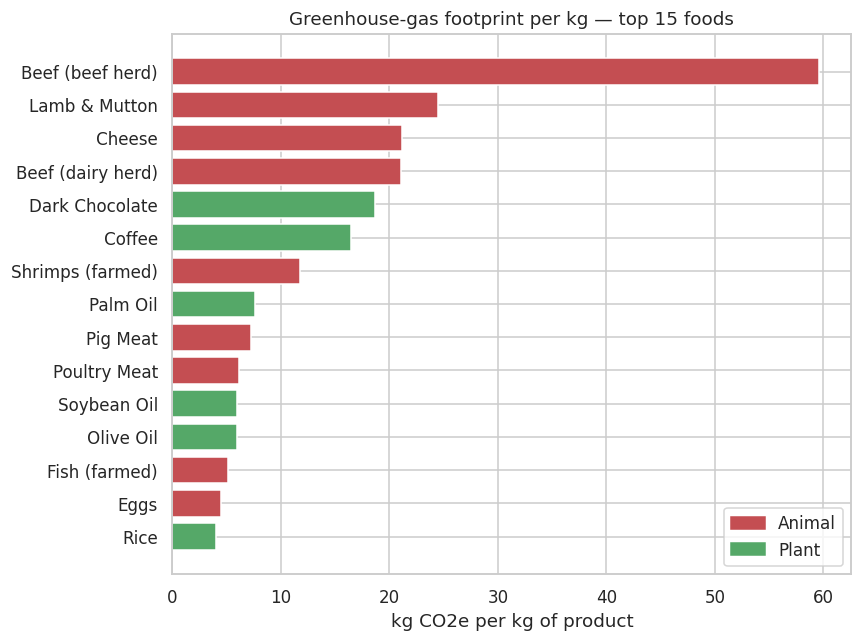

In [3]:
top = d.nlargest(15, GHG).sort_values(GHG)
plt.figure(figsize=(8,6))
plt.barh(top["Food product"], top[GHG], color=top["type"].map({"Animal":"#c44e52","Plant":"#55a868"}))
plt.xlabel("kg CO2e per kg of product"); plt.title("Greenhouse-gas footprint per kg — top 15 foods")
plt.legend(handles=[mp.Patch(color="#c44e52",label="Animal"),mp.Patch(color="#55a868",label="Plant")])
plt.tight_layout(); plt.savefig("figures/01_ghg_ranking.png"); plt.show()

## 2. Where do emissions come from? (the "food-miles" myth)
Breaking each food's GHG into supply-chain stages shows the popular focus on *transport* is misplaced: for animal products, **farm + feed + land-use change** is where almost all emissions sit, while transport and packaging are slivers.

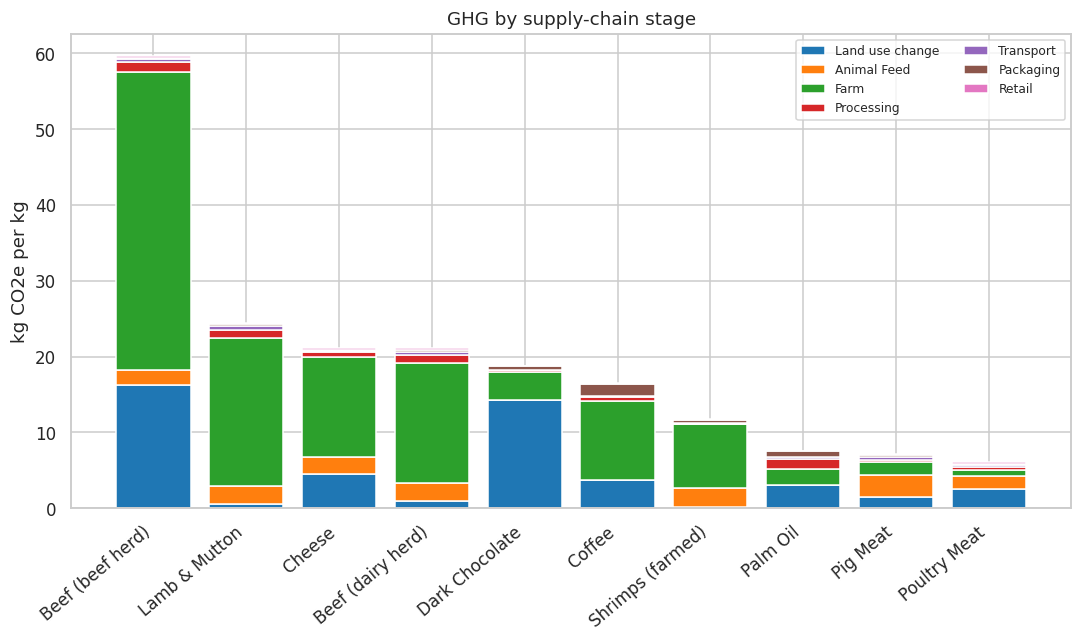

Across animal products: transport+packaging = 4.7% of GHG
                        farm+feed+land-use change = 90.1%
Beef: transport is just 0.5% of its footprint


In [4]:
t10 = d.nlargest(10, GHG).set_index("Food product")[STAGES]
plt.figure(figsize=(10,6)); bottom=np.zeros(len(t10)); pal=sns.color_palette("tab10",len(STAGES))
for i,s in enumerate(STAGES):
    plt.bar(t10.index, t10[s], bottom=bottom, label=s, color=pal[i]); bottom+=t10[s].values
plt.xticks(rotation=40, ha="right"); plt.ylabel("kg CO2e per kg"); plt.title("GHG by supply-chain stage")
plt.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.savefig("figures/02_stage_decomposition.png"); plt.show()

an=d[d.type=="Animal"].copy()
for s in STAGES: an[s+"_sh"]=an[s]/an[GHG]
print(f"Across animal products: transport+packaging = {(an['Transport_sh']+an['Packaging_sh']).mean()*100:.1f}% of GHG")
print(f"                        farm+feed+land-use change = {(an['Farm_sh']+an['Animal Feed_sh']+an['Land use change_sh']).mean()*100:.1f}%")
bf=d[d['Food product']=='Beef (beef herd)'].iloc[0]; print(f"Beef: transport is just {bf['Transport']/bf[GHG]*100:.1f}% of its footprint")

## 3. Is carbon a good proxy for the other impacts?
If GHG tracked every other impact perfectly, we'd only need to measure carbon. It mostly does — **except water**.

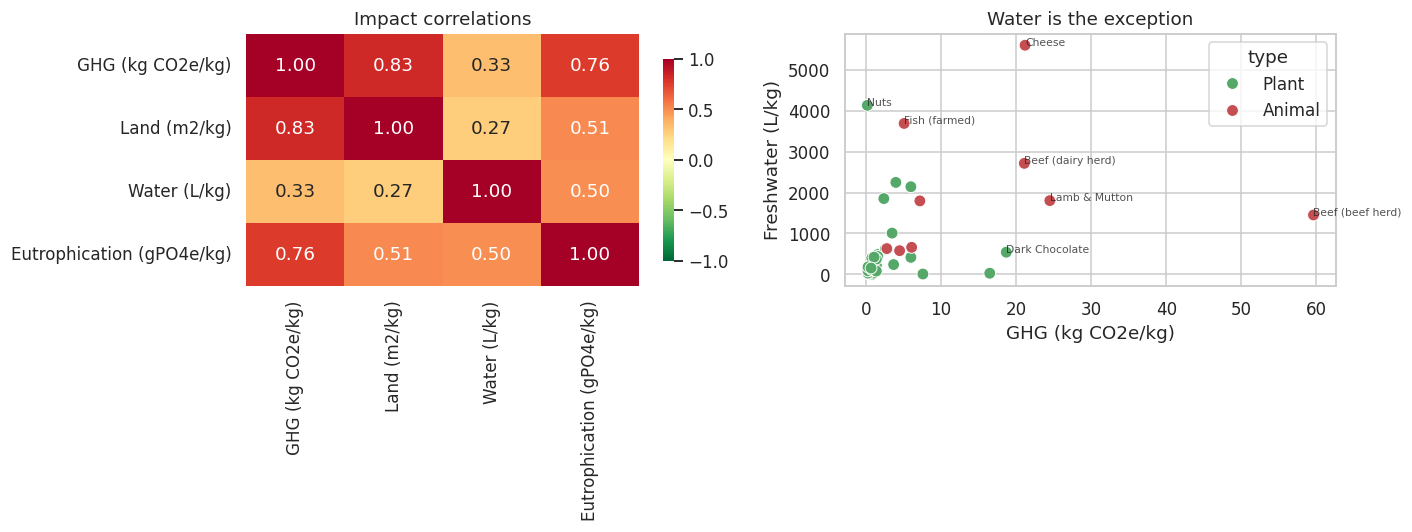

Correlation with GHG -> Land 0.83, Water 0.33, Eutrophication 0.76


In [5]:
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,5))
cor=d[[GHG,LAND,WATER,EUT]].corr(); cor.index=list(IMPACTS); cor.columns=list(IMPACTS)
sns.heatmap(cor,annot=True,fmt=".2f",cmap="RdYlGn_r",vmin=-1,vmax=1,ax=a1,cbar_kws={"shrink":.8}); a1.set_title("Impact correlations")
sns.scatterplot(data=d,x=GHG,y=WATER,hue="type",palette={"Animal":"#c44e52","Plant":"#55a868"},s=60,ax=a2)
for _,r in d.iterrows():
    if r[WATER]>d[WATER].quantile(.9) or r[GHG]>d[GHG].quantile(.9): a2.annotate(r["Food product"],(r[GHG],r[WATER]),fontsize=7,alpha=.8)
a2.set_xlabel("GHG (kg CO2e/kg)"); a2.set_ylabel("Freshwater (L/kg)"); a2.set_title("Water is the exception")
plt.tight_layout(); plt.savefig("figures/03_multi_impact.png"); plt.show()
print(f"Correlation with GHG -> Land {cor.iloc[0,1]:.2f}, Water {cor.iloc[0,2]:.2f}, Eutrophication {cor.iloc[0,3]:.2f}")

## 4. Foods in "impact space" (PCA)
Reducing the four impacts to two components gives a map of the food system. PC1 is an overall-impact axis; PC2 separates the water-intensive foods. (Five foods with incomplete impact data are dropped here — imputing environmental values would mean inventing data.)

Using 38 of 43 foods | PC1=66%  PC2=21%


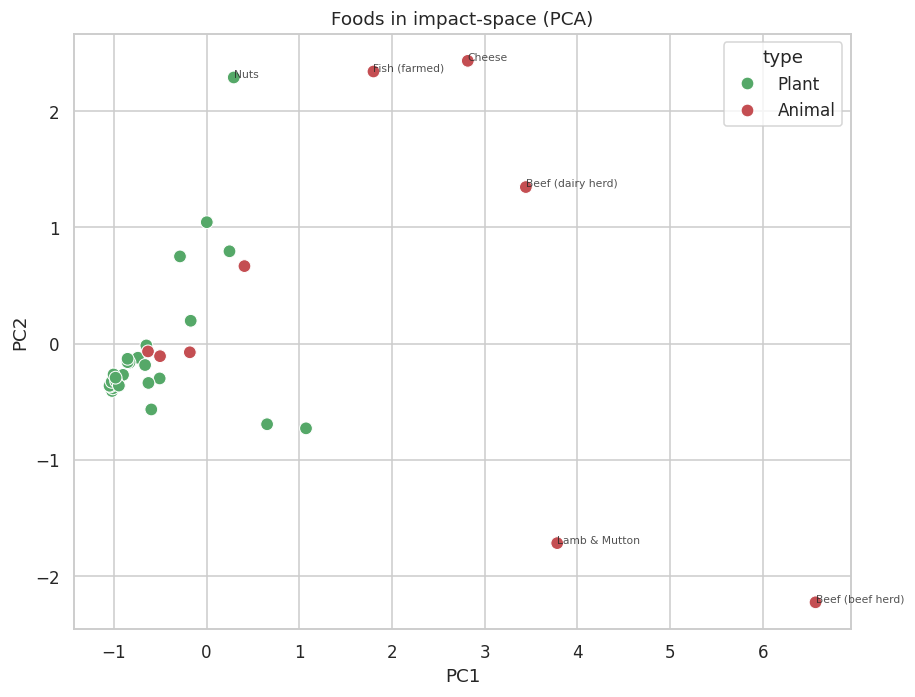

In [6]:
feat=[GHG,LAND,WATER,EUT]; dd=d.dropna(subset=feat).reset_index(drop=True).copy()
X=StandardScaler().fit_transform(dd[feat]); pca=PCA(n_components=2); pc=pca.fit_transform(X)
dd["PC1"],dd["PC2"]=pc[:,0],pc[:,1]
print(f"Using {len(dd)} of {len(d)} foods | PC1={pca.explained_variance_ratio_[0]*100:.0f}%  PC2={pca.explained_variance_ratio_[1]*100:.0f}%")
plt.figure(figsize=(8.5,6.5))
sns.scatterplot(data=dd,x="PC1",y="PC2",hue="type",palette={"Animal":"#c44e52","Plant":"#55a868"},s=70)
for _,r in dd.iterrows():
    if abs(r.PC1)>2 or abs(r.PC2)>2: plt.annotate(r["Food product"],(r.PC1,r.PC2),fontsize=7,alpha=.8)
plt.title("Foods in impact-space (PCA)"); plt.tight_layout(); plt.savefig("figures/04_pca.png"); plt.show()

## 5. Environmental archetypes (clustering)
k-means on the standardised impacts groups the 43 foods into four archetypes — from low-impact staples to the extreme ruminant corner.

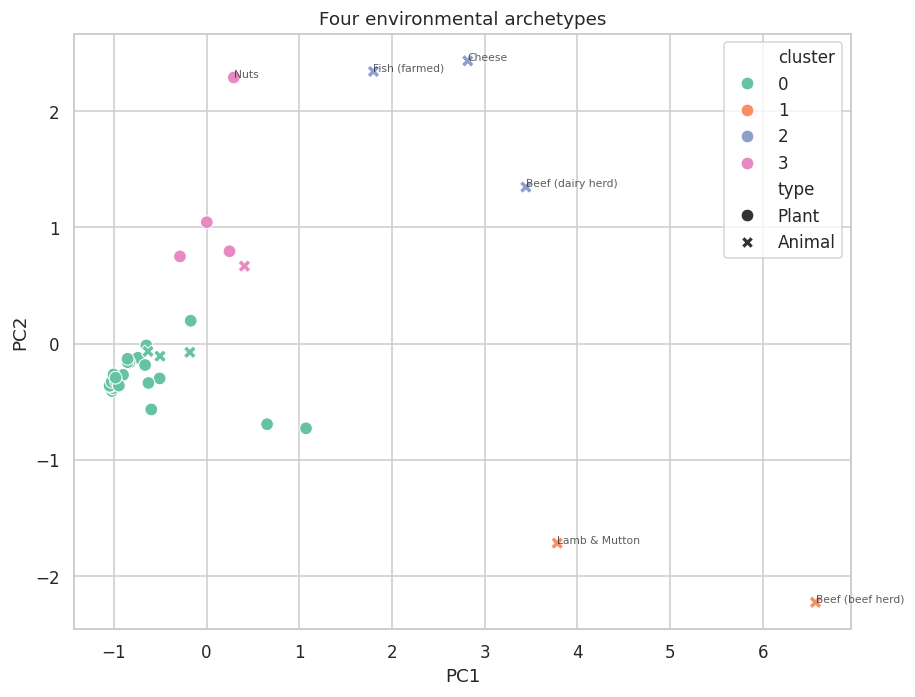

          n   GHG   Land   Water  Eutroph
cluster                                  
0        28   3.1    7.4   285.8     16.9
3         5   4.0   13.7  2434.4     36.4
2         3  15.8   46.5  4003.6    232.9
1         2  42.0  348.0  1627.0    199.3
  cluster 0: Oatmeal, Potatoes, Cassava, Cane Sugar, Beet Sugar
  cluster 3: Rice, Nuts, Groundnuts, Olive Oil, Pig Meat
  cluster 2: Beef (dairy herd), Cheese, Fish (farmed)
  cluster 1: Beef (beef herd), Lamb & Mutton


In [7]:
dd["cluster"]=KMeans(n_clusters=4,n_init=10,random_state=42).fit_predict(X)
plt.figure(figsize=(8.5,6.5))
sns.scatterplot(data=dd,x="PC1",y="PC2",hue="cluster",palette="Set2",s=70,style="type")
for _,r in dd.iterrows():
    if abs(r.PC1)>2 or abs(r.PC2)>2: plt.annotate(r["Food product"],(r.PC1,r.PC2),fontsize=7,alpha=.75)
plt.title("Four environmental archetypes"); plt.tight_layout(); plt.savefig("figures/05_clusters.png"); plt.show()
prof=dd.groupby("cluster").agg(n=("Food product","size"),GHG=(GHG,"mean"),Land=(LAND,"mean"),
     Water=(WATER,"mean"),Eutroph=(EUT,"mean")).round(1).sort_values("GHG")
print(prof.to_string())
for cl in prof.index: print(f"  cluster {cl}: {', '.join(dd[dd.cluster==cl]['Food product'].head(5))}")

## 6. A fair fight: GHG per 100g of protein
Comparing per kg is unfair to nutrient-dense foods. Re-basing on **protein delivered** (and restricting to foods actually eaten as protein sources — per-protein figures are meaningless for chocolate or tomatoes) shows the ranking is robust: plant proteins sit far below animal ones, with **eggs** the lowest-impact animal option.

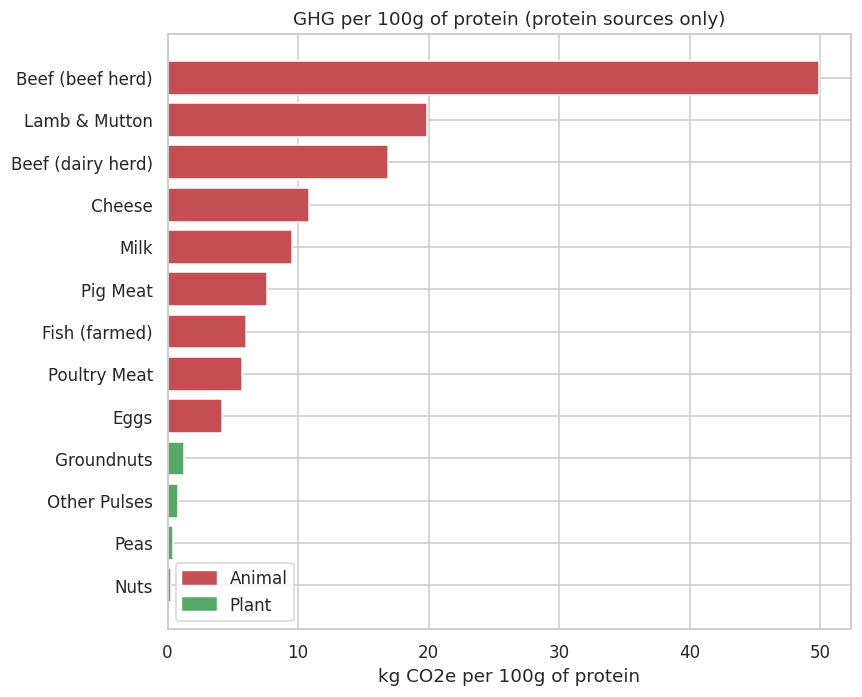

Lowest-impact protein sources:
Food product  Greenhouse gas emissions per 100g protein (kgCO₂eq per 100g protein)
        Nuts                                                              0.263319
        Peas                                                              0.441044
Other Pulses                                                              0.836058
  Groundnuts                                                              1.233766
        Eggs                                                              4.208724


In [8]:
PROTEIN_FOODS={"Beef (beef herd)","Beef (dairy herd)","Lamb & Mutton","Pig Meat","Poultry Meat",
   "Fish (farmed)","Shrimps (farmed)","Eggs","Cheese","Milk","Tofu","Soymilk","Peas","Other Pulses","Groundnuts","Nuts"}
prot=d[d["Food product"].isin(PROTEIN_FOODS)].dropna(subset=[GHG_P]).sort_values(GHG_P)
plt.figure(figsize=(8,6.5))
plt.barh(prot["Food product"], prot[GHG_P], color=prot["type"].map({"Animal":"#c44e52","Plant":"#55a868"}))
plt.xlabel("kg CO2e per 100g of protein"); plt.title("GHG per 100g of protein (protein sources only)")
plt.legend(handles=[mp.Patch(color="#c44e52",label="Animal"),mp.Patch(color="#55a868",label="Plant")])
plt.tight_layout(); plt.savefig("figures/06_per_protein.png"); plt.show()
print("Lowest-impact protein sources:"); print(prot.nsmallest(5,GHG_P)[["Food product",GHG_P]].to_string(index=False))

## Key findings
1. **Stage matters more than distance.** Transport + packaging ≈ 5% of animal-product GHG; the farm/feed/land block is ~90%. The "buy local to save the planet" intuition is largely wrong — *what* you eat dominates.
2. **Carbon is a decent proxy — except for water.** GHG correlates strongly with land (0.83) and eutrophication (0.76) but weakly with freshwater (0.33); some plants (nuts, rice) are the most water-hungry foods.
3. **The animal/plant gap survives fair comparison.** Per 100g of protein, ruminant meat is ~50–100× the footprint of pulses or nuts; eggs are the most efficient animal protein.
4. **Foods cluster into clear archetypes**, with beef and lamb isolated in a high-impact, high-land corner.

## Limitations
- **Still per-product global means.** This does *not* capture producer-to-producer variation (the unresolved half of Project 1's limitation #1) — that needs percentile data not accessible here.
- **Published figures disagree.** The same study, processed differently, gives beef ~60 vs ~99.5 kg CO₂e/kg; treat absolute numbers cautiously and lean on relative rankings.
- **Small sample (43 foods).** PCA and clustering are illustrative, not definitive; clusters can shift with the food list.
- **"Per 100g protein" ignores protein quality** — amino-acid completeness and digestibility differ between, say, beef and peas.
- **Demand- and trade-side questions remain** (production vs consumption, country coverage) — untouched here.

## Where this leaves the portfolio
Project 1 asked *how much* and *what mix*; Project 2 asks *where the impact comes from* and *across which dimensions*. The honest open problem — **producer-level variation** — is the natural Project 3, and it's exactly the question a production-focused consultancy works on.

---
*Data: Poore & Nemecek (2018), Science, via a public GitHub mirror of the Kaggle release. Built as a portfolio project.*